## 1. Setup
Imports and dataset configuration.

In [1]:
from pathlib import Path
from collections import defaultdict
import json
import hashlib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import hashlib

In [2]:
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 11
raw_path = Path.cwd() / "data" / "raw"
dataset_root = Path(raw_path)

## 2. Counts by split and class


In [3]:
counts = defaultdict(lambda: defaultdict(int))
file_lists = defaultdict(lambda: defaultdict(list))
splits = ["train", "val", "test"]

for split in splits:
    split_dir = dataset_root / split
    if not split_dir.exists():
        continue
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        cls = class_dir.name
        files = [f for f in class_dir.iterdir() if f.suffix.lower() in (".jpeg", ".jpg", ".png", ".jfif")]
        counts[split][cls] = len(files)
        file_lists[split][cls] = files

grand_total = sum(sum(c.values()) for c in counts.values())
splits_ok = [s for s in splits if s in counts]
classes = sorted(set().union(*(set(counts[s].keys()) for s in splits_ok)))

### 3. Class imbalance


In [4]:
# Class imbalance analysis
for split in splits_ok:
    total = sum(counts[split].values())
    ratios = {cls: counts[split].get(cls, 0) / total * 100 for cls in classes}
    print(f"  {split}: " + " | ".join(f"{cls}={ratios[cls]:.1f}%" for cls in classes))

# PNEUMONIA/NORMAL ratio in train
if "train" in counts and counts["train"].get("NORMAL", 0) > 0:
    ratio = counts["train"]["PNEUMONIA"] / counts["train"]["NORMAL"]
    print(f"\n  Ratio PNEUMONIA/NORMAL (train): {ratio:.2f}x")

  train: NORMAL=25.7% | PNEUMONIA=74.3%
  val: NORMAL=50.0% | PNEUMONIA=50.0%
  test: NORMAL=37.5% | PNEUMONIA=62.5%

  Ratio PNEUMONIA/NORMAL (train): 2.89x


### 4. File integrity


In [5]:
corrupt = []
for split in splits:
    for cls, files in file_lists.get(split, {}).items():
        for path in files:
            try:
                with Image.open(path) as img:
                    img.verify()
            except Exception as e:
                corrupt.append((str(path), str(e)))
corrupt_paths = {t[0] for t in corrupt}  # set of paths for downstream use
print(f"Corrupt or unreadable files: {len(corrupt)}")
if corrupt:
    for path, err in corrupt[:5]:
        print(f"  {path}: {err}")

Corrupt or unreadable files: 0


### 5. Storage


In [6]:
# Storage stats: total size and avg file size
total_bytes = 0
n_files = 0
for split in splits:
    for cls, files in file_lists.get(split, {}).items():
        for p in files:
            try:
                total_bytes += p.stat().st_size
                n_files += 1
            except OSError:
                pass
total_mb = total_bytes / (1024 * 1024)
avg_kb = (total_bytes / n_files / 1024) if n_files else 0
print(f"Total size: {total_mb:.2f} MB  |  Avg file size: {avg_kb:.1f} KB  |  Files: {n_files}")

Total size: 1179.20 MB  |  Avg file size: 206.2 KB  |  Files: 5856


### 6. Duplicate detection


In [7]:
def file_hash(path, limit_mb=50):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
            if f.tell() > limit_mb * (1 << 20):
                break
    return h.hexdigest()

hash_to_paths = defaultdict(list)
for split in splits:
    for cls, files in file_lists.get(split, {}).items():
        for p in files:
            if str(p) not in corrupt_paths:
                try:
                    h = file_hash(p)
                    hash_to_paths[h].append((str(p), split, cls))
                except Exception:
                    pass

duplicates = {h: paths for h, paths in hash_to_paths.items() if len(paths) > 1}
if duplicates:
    print(f"⚠️ Found {len(duplicates)} duplicate image(s) (same content):")
    for h, paths in list(duplicates.items())[:3]:
        print(f"  Hash {h[:12]}... appears in: {[p[0].split('/')[-1] for p in paths]}")
else:
    print("✓ No duplicate images detected (by content hash)")

⚠️ Found 30 duplicate image(s) (same content):
  Hash dcc3ab0eaf19... appears in: ['NORMAL2-IM-0587-0001-0001.jpeg', 'NORMAL2-IM-0587-0001-0002.jpeg']
  Hash 99e09ba874a3... appears in: ['person258_bacteria_1207.jpeg', 'person258_bacteria_1209.jpeg', 'person258_bacteria_1208.jpeg']
  Hash ec767162c138... appears in: ['person1481_bacteria_3862.jpeg', 'person1481_bacteria_3863.jpeg']


## 7. Visualizations

Bar charts, image samples, extensions and dimensions.


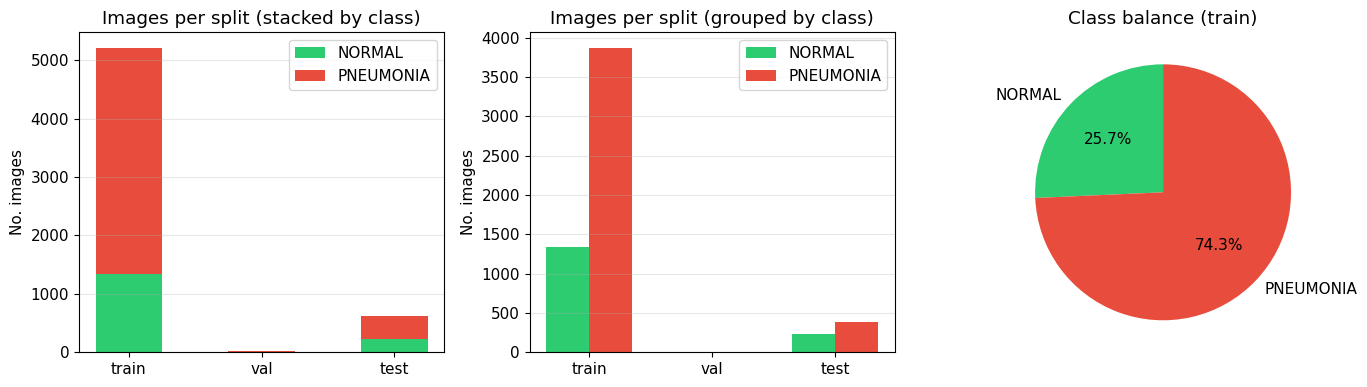

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

splits_ok = [s for s in splits if s in counts]
x = np.arange(len(splits_ok))
width = 0.5
classes = sorted(set().union(*(set(counts[s].keys()) for s in splits_ok)))
bottom = np.zeros(len(splits_ok))
colors = {"NORMAL": "#2ecc71", "PNEUMONIA": "#e74c3c"}
for cls in classes:
    vals = [counts[s].get(cls, 0) for s in splits_ok]
    axes[0].bar(x, vals, width, label=cls, bottom=bottom, color=colors.get(cls, "gray"))
    bottom += vals
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits_ok)
axes[0].set_ylabel("No. images")
axes[0].set_title("Images per split (stacked by class)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

x = np.arange(len(splits_ok))
w = 0.35
for i, cls in enumerate(classes):
    vals = [counts[s].get(cls, 0) for s in splits_ok]
    axes[1].bar(x + (i - 0.5) * w, vals, w, label=cls, color=colors.get(cls, "gray"))
axes[1].set_xticks(x)
axes[1].set_xticklabels(splits_ok)
axes[1].set_ylabel("No. images")
axes[1].set_title("Images per split (grouped by class)")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

train_tot = sum(counts["train"].values()) if "train" in counts else 0
if train_tot > 0:
    sizes = [counts["train"].get(c, 0) for c in classes]
    axes[2].pie(sizes, labels=classes, autopct="%1.1f%%", colors=[colors.get(c, "gray") for c in classes],
                startangle=90)
    axes[2].set_title("Class balance (train)")
plt.tight_layout()
plt.show()

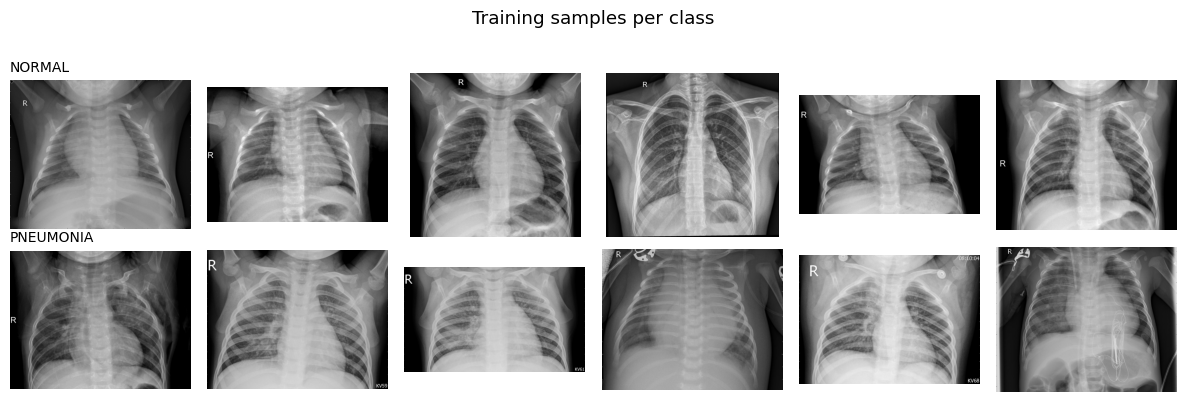

In [9]:
# Sample grid: one row per class (from train)
n_per_class = 6
fig, axes = plt.subplots(len(classes), n_per_class, figsize=(12, 2 * len(classes)))
if len(classes) == 1:
    axes = axes.reshape(1, -1)
for row, cls in enumerate(classes):
    files = file_lists.get("train", {}).get(cls, [])[:n_per_class]
    for col in range(n_per_class):
        ax = axes[row, col]
        if col < len(files):
            with Image.open(files[col]) as img:
                ax.imshow(img, cmap="gray")
            ax.set_title(f"{cls}" if col == 0 else "", loc="left", fontsize=10)
        ax.axis("off")
plt.suptitle("Training samples per class", y=1.02)
plt.tight_layout()
plt.show()

In [10]:
extensions = defaultdict(int)
dimensions = []  # (width, height) per file
max_samples = 2000  # limit to avoid long runs; None = all

n = 0
for split in splits:
    for cls, files in file_lists.get(split, {}).items():
        for path in files:
            if max_samples and n >= max_samples:
                break
            extensions[path.suffix.lower()] += 1
            with Image.open(path) as img:
                w, h = img.size
                dimensions.append((w, h))
            n += 1
    if max_samples and n >= max_samples:
        break

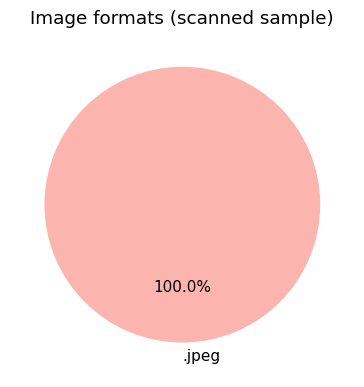

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
exts = list(extensions.keys())
vals = [extensions[e] for e in exts]
ax.pie(vals, labels=exts, autopct="%1.1f%%", startangle=90, colors=plt.cm.Pastel1(np.linspace(0, 1, len(exts))))
ax.set_title("Image formats (scanned sample)")
plt.tight_layout()
plt.show()

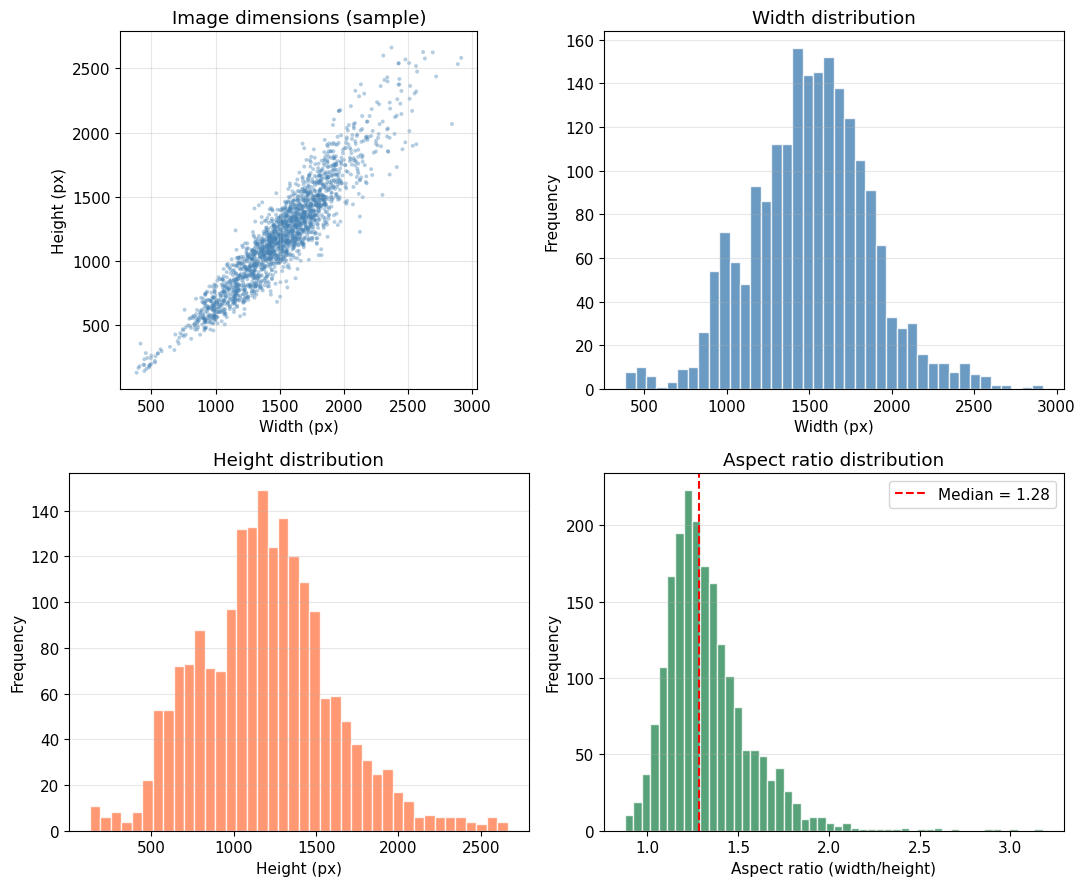

In [12]:
ww, hh = zip(*dimensions)
aspect = [w / h if h else 0 for w, h in dimensions]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# Scatter width vs height
axes[0, 0].scatter(ww, hh, alpha=0.4, s=8, c="steelblue", edgecolors="none")
axes[0, 0].set_xlabel("Width (px)")
axes[0, 0].set_ylabel("Height (px)")
axes[0, 0].set_title("Image dimensions (sample)")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_aspect("equal", adjustable="box")

# Width histogram
axes[0, 1].hist(ww, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
axes[0, 1].set_xlabel("Width (px)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Width distribution")
axes[0, 1].grid(axis="y", alpha=0.3)

# Height histogram
axes[1, 0].hist(hh, bins=40, color="coral", edgecolor="white", alpha=0.8)
axes[1, 0].set_xlabel("Height (px)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Height distribution")
axes[1, 0].grid(axis="y", alpha=0.3)

# Aspect ratio histogram
axes[1, 1].hist(aspect, bins=50, color="seagreen", edgecolor="white", alpha=0.8)
axes[1, 1].axvline(np.median(aspect), color="red", linestyle="--", label=f"Median = {np.median(aspect):.2f}")
axes[1, 1].set_xlabel("Aspect ratio (width/height)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Aspect ratio distribution")
axes[1, 1].legend()
axes[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

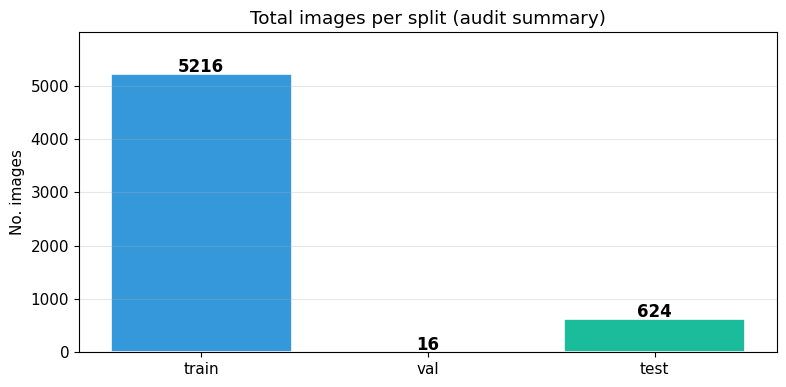

Total dataset: 5856 images  |  Corrupt files: 0


In [13]:
# Visual summary of the audit
fig, ax = plt.subplots(figsize=(8, 4))
splits_ok = [s for s in splits if s in counts]
totals = [sum(counts[s].values()) for s in splits_ok]
bars = ax.bar(splits_ok, totals, color=["#3498db", "#9b59b6", "#1abc9c"], edgecolor="white", linewidth=1.2)
ax.set_ylabel("No. images")
ax.set_title("Total images per split (audit summary)")
for bar, t in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30, str(t), ha="center", fontsize=12,
            fontweight="bold")
ax.set_ylim(0, max(totals) * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Total dataset: {grand_total} images  |  Corrupt files: {len(corrupt)}")

### 8. Export summary


In [14]:
# Export audit summary to config
import json
from pathlib import Path

summary = {
    "dataset_root": str(dataset_root),
    "counts": {s: dict(counts[s]) for s in splits if s in counts},
    "totals_per_split": {s: sum(counts[s].values()) for s in splits if s in counts},
    "grand_total": grand_total,
    "extensions": dict(extensions),
    "corrupt_count": len(corrupt_paths),
    "total_size_mb": round(total_bytes / (1024 * 1024), 2),
    "unique_dimensions_sample": [list(d) for d in list(set(dimensions))[:30]] if dimensions else [],
}

out_path = Path("config") / "audit_summary.json"
out_path.parent.mkdir(exist_ok=True)
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"✓ Audit summary exported to {out_path}")

✓ Audit summary exported to config/audit_summary.json
